# Wind Forecast Monitoring and Reliability Analysis

## Objective

This notebook analyzes UK national wind generation forecasts for January 2024 using the Elexon BMRS datasets.

The work has two goals:

1. **Forecast error analysis**  
   Understand the error characteristics of the forecast dataset, including:
   - overall error distribution
   - variation with forecast horizon
   - variation by time of day

2. **Wind reliability analysis**  
   Analyze historical actual wind generation and recommend how many MW of wind power can be **reliably expected** to be available to meet electricity demand.

## Scope

- Geography: United Kingdom national-level wind generation
- Period: January 2024
- Actuals dataset: `FUELHH` filtered to `fuelType = WIND`
- Forecast dataset: `WINDFOR`
- Forecast horizon range considered: `0–48 hours`

## Important modeling rule used in the app

For each target time and chosen forecast horizon `H`, the forecast used is:

- the **latest available forecast**
- whose `publishTime <= startTime - H`

This matches the assignment requirement:
> show the value of the latest forecast which was created at least H hours before each target time.

## Notes

During exploration, I found that:
- actual generation values are available every **30 minutes**
- forecast target times in the retrieved January 2024 data are available mostly at **hourly** timestamps

Because of that, forecast coverage is incomplete when aligning directly against all 30-minute actual timestamps. Missing forecasts are left missing rather than imputed.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [3]:
PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data"
RAW_DATA_ROOT = DATA_ROOT / "raw"

ACTUALS_PATH = RAW_DATA_ROOT / "actuals_jan_2024.csv"
FORECASTS_PATH = RAW_DATA_ROOT / "forecasts_jan_2024.csv"

print("Actuals path exists:", ACTUALS_PATH.exists(), ACTUALS_PATH)
print("Forecasts path exists:", FORECASTS_PATH.exists(), FORECASTS_PATH)

Actuals path exists: True C:\Users\deepa\deepanshu\REint-wind-forecast\data\raw\actuals_jan_2024.csv
Forecasts path exists: True C:\Users\deepa\deepanshu\REint-wind-forecast\data\raw\forecasts_jan_2024.csv


In [4]:
actuals = pd.read_csv(ACTUALS_PATH)
forecasts = pd.read_csv(FORECASTS_PATH)

print("Actuals shape:", actuals.shape)
print("Forecasts shape:", forecasts.shape)

Actuals shape: (1488, 4)
Forecasts shape: (9582, 4)


In [5]:
actuals.head()

,startTime,settlementDate,fuelType,generation
0,2024-01-01 00:00:00+00:00,2024-01-01,WIND,10402
1,2024-01-01 00:30:00+00:00,2024-01-01,WIND,10845
2,2024-01-01 01:00:00+00:00,2024-01-01,WIND,11218
3,2024-01-01 01:30:00+00:00,2024-01-01,WIND,11223
4,2024-01-01 02:00:00+00:00,2024-01-01,WIND,11234


In [6]:
forecasts.head()

,publishTime,startTime,generation,horizon_hours
0,2024-01-01 02:30:00+00:00,2024-01-01 21:00:00+00:00,9426,18.5
1,2024-01-01 04:30:00+00:00,2024-01-01 21:00:00+00:00,9432,16.5
2,2024-01-01 07:30:00+00:00,2024-01-01 21:00:00+00:00,10065,13.5
3,2024-01-01 09:30:00+00:00,2024-01-01 21:00:00+00:00,10065,11.5
4,2024-01-01 11:30:00+00:00,2024-01-01 21:00:00+00:00,10072,9.5


In [7]:
actuals["startTime"] = pd.to_datetime(actuals["startTime"], utc=True)

if "publishTime" in actuals.columns:
    actuals["publishTime"] = pd.to_datetime(actuals["publishTime"], utc=True, errors="coerce")

forecasts["startTime"] = pd.to_datetime(forecasts["startTime"], utc=True)
forecasts["publishTime"] = pd.to_datetime(forecasts["publishTime"], utc=True)

if "horizon_hours" in forecasts.columns:
    forecasts["horizon_hours"] = forecasts["horizon_hours"].astype(float)
else:
    forecasts["horizon_hours"] = (
        forecasts["startTime"] - forecasts["publishTime"]
    ).dt.total_seconds() / 3600

## 1. Initial data quality checks

Before analyzing forecast errors, I first verify:
- dataset size
- column availability
- time range
- duplicates
- missing values
- timestamp cadence

In [8]:
print("Actuals columns:", list(actuals.columns))
print("Forecasts columns:", list(forecasts.columns))

Actuals columns: ['startTime', 'settlementDate', 'fuelType', 'generation']
Forecasts columns: ['publishTime', 'startTime', 'generation', 'horizon_hours']


In [9]:
summary_rows = [
    {
        "dataset": "actuals",
        "rows": len(actuals),
        "min_startTime": actuals["startTime"].min(),
        "max_startTime": actuals["startTime"].max(),
        "missing_startTime": actuals["startTime"].isna().sum(),
        "missing_generation": actuals["generation"].isna().sum(),
    },
    {
        "dataset": "forecasts",
        "rows": len(forecasts),
        "min_startTime": forecasts["startTime"].min(),
        "max_startTime": forecasts["startTime"].max(),
        "missing_startTime": forecasts["startTime"].isna().sum(),
        "missing_publishTime": forecasts["publishTime"].isna().sum(),
        "missing_generation": forecasts["generation"].isna().sum(),
    },
]

pd.DataFrame(summary_rows)

,dataset,rows,min_startTime,max_startTime,missing_startTime,missing_generation,missing_publishTime
0,actuals,1488,2024-01-01 00:00:00+00:00,2024-01-31 23:30:00+00:00,0,0,NaN
1,forecasts,9582,2024-01-01 21:00:00+00:00,2024-02-02 21:00:00+00:00,0,0,0.0


In [10]:
actual_duplicates = actuals.duplicated(subset=["startTime"]).sum()
forecast_duplicates = forecasts.duplicated(subset=["startTime", "publishTime"]).sum()

print("Duplicate actual timestamps:", actual_duplicates)
print("Duplicate forecast (startTime, publishTime) pairs:", forecast_duplicates)

Duplicate actual timestamps: 0
Duplicate forecast (startTime, publishTime) pairs: 0


In [11]:
actual_time_diffs = actuals["startTime"].sort_values().diff().dropna()
forecast_target_diffs = forecasts["startTime"].sort_values().diff().dropna()

print("Actual cadence counts:")
print(actual_time_diffs.value_counts().head(10))

print("\nForecast target-time cadence counts:")
print(forecast_target_diffs.value_counts().head(10))

Actual cadence counts:
startTime
0 days 00:30:00    1487
Name: count, dtype: int64

Forecast target-time cadence counts:
startTime
0 days 00:00:00    8813
0 days 01:00:00     768
Name: count, dtype: int64


In [12]:
actual_minutes = sorted(actuals["startTime"].dt.minute.astype(str).str.zfill(2).unique())
forecast_minutes = sorted(forecasts["startTime"].dt.minute.astype(str).str.zfill(2).unique())

print("Unique minute values in actual target times:", actual_minutes)
print("Unique minute values in forecast target times:", forecast_minutes)

Unique minute values in actual target times: ['00', '30']
Unique minute values in forecast target times: ['00']


## Interpretation of data quality checks

Key observations from the raw data inspection:

1. **Actual generation series is half-hourly**  
   The actuals dataset provides target times at 30-minute resolution.

2. **Forecast target times are mostly hourly**  
   The retrieved forecast dataset for January 2024 appears to contain target timestamps mainly on the hour.

3. **Consequence for monitoring and analysis**  
   When matching actuals and forecasts by exact target timestamp, some actual half-hour timestamps do not have a corresponding forecast point. These cases should remain missing rather than being interpolated in the analytical dataset.

This is important because forecast coverage and error statistics should be interpreted only over timestamps where an eligible forecast actually exists.

In [13]:
print("Actuals date range:")
print(actuals["startTime"].min(), "to", actuals["startTime"].max())

print("\nForecast publish time range:")
print(forecasts["publishTime"].min(), "to", forecasts["publishTime"].max())

print("\nForecast target time range:")
print(forecasts["startTime"].min(), "to", forecasts["startTime"].max())

print("\nForecast horizon summary:")
print(forecasts["horizon_hours"].describe())

Actuals date range:
2024-01-01 00:00:00+00:00 to 2024-01-31 23:30:00+00:00

Forecast publish time range:
2024-01-01 02:30:00+00:00 to 2024-01-31 22:30:00+00:00

Forecast target time range:
2024-01-01 21:00:00+00:00 to 2024-02-02 21:00:00+00:00

Forecast horizon summary:
count    9582.000000
mean       28.081507
std        11.952671
min         0.500000
25%        18.500000
50%        28.500000
75%        38.500000
max        48.000000
Name: horizon_hours, dtype: float64


## 2. Build evaluation dataset for a fixed forecast horizon

To analyze forecast error, I need a comparison table with:

- target time
- actual generation
- selected forecast generation
- forecast publish time
- effective forecast horizon
- error metrics

For a given horizon `H`, I select the latest forecast such that:

`publishTime <= startTime - H`

In [14]:
def build_monitoring_dataset(
    actuals_df: pd.DataFrame,
    forecasts_df: pd.DataFrame,
    horizon_hours: float,
) -> pd.DataFrame:
    actuals_local = actuals_df.copy()
    forecasts_local = forecasts_df.copy()

    actuals_local["startTime"] = pd.to_datetime(actuals_local["startTime"], utc=True)
    forecasts_local["startTime"] = pd.to_datetime(forecasts_local["startTime"], utc=True)
    forecasts_local["publishTime"] = pd.to_datetime(forecasts_local["publishTime"], utc=True)

    actuals_local = actuals_local.sort_values("startTime").reset_index(drop=True)
    forecasts_local = forecasts_local.sort_values(["startTime", "publishTime"]).reset_index(drop=True)

    selected_rows = []

    horizon_delta = pd.to_timedelta(horizon_hours, unit="h")

    for _, actual_row in actuals_local.iterrows():
        target_time = actual_row["startTime"]
        cutoff_time = target_time - horizon_delta

        candidates = forecasts_local[
            (forecasts_local["startTime"] == target_time)
            & (forecasts_local["publishTime"] <= cutoff_time)
        ]

        if candidates.empty:
            selected_rows.append(
                {
                    "startTime": target_time,
                    "actual_generation": actual_row["generation"],
                    "forecast_generation": np.nan,
                    "publishTime": pd.NaT,
                    "effective_horizon_hours": np.nan,
                }
            )
            continue

        chosen = candidates.sort_values("publishTime").iloc[-1]

        effective_horizon_hours = (
            target_time - chosen["publishTime"]
        ).total_seconds() / 3600

        selected_rows.append(
            {
                "startTime": target_time,
                "actual_generation": actual_row["generation"],
                "forecast_generation": chosen["generation"],
                "publishTime": chosen["publishTime"],
                "effective_horizon_hours": effective_horizon_hours,
            }
        )

    result = pd.DataFrame(selected_rows)
    result["error_mw"] = result["forecast_generation"] - result["actual_generation"]
    result["abs_error_mw"] = result["error_mw"].abs()

    return result

In [15]:
evaluation_h4 = build_monitoring_dataset(actuals, forecasts, horizon_hours=4.0)

print("Evaluation dataset shape:", evaluation_h4.shape)
evaluation_h4.head(10)

Evaluation dataset shape: (1488, 7)


,startTime,actual_generation,forecast_generation,publishTime,effective_horizon_hours,error_mw,abs_error_mw
0,2024-01-01 00:00:00+00:00,10402,NaN,NaT,NaN,NaN,NaN
1,2024-01-01 00:30:00+00:00,10845,NaN,NaT,NaN,NaN,NaN
2,2024-01-01 01:00:00+00:00,11218,NaN,NaT,NaN,NaN,NaN
3,2024-01-01 01:30:00+00:00,11223,NaN,NaT,NaN,NaN,NaN
4,2024-01-01 02:00:00+00:00,11234,NaN,NaT,NaN,NaN,NaN
5,2024-01-01 02:30:00+00:00,11437,NaN,NaT,NaN,NaN,NaN
6,2024-01-01 03:00:00+00:00,11434,NaN,NaT,NaN,NaN,NaN
7,2024-01-01 03:30:00+00:00,11445,NaN,NaT,NaN,NaN,NaN
8,2024-01-01 04:00:00+00:00,11828,NaN,NaT,NaN,NaN,NaN
9,2024-01-01 04:30:00+00:00,11878,NaN,NaT,NaN,NaN,NaN


In [16]:
coverage_h4 = evaluation_h4["forecast_generation"].notna().mean()

print("Forecast coverage at 4h horizon:", round(coverage_h4, 4))
print("Rows with forecast:", evaluation_h4["forecast_generation"].notna().sum())
print("Rows without forecast:", evaluation_h4["forecast_generation"].isna().sum())

Forecast coverage at 4h horizon: 0.4859
Rows with forecast: 723
Rows without forecast: 765


In [17]:
evaluation_h4[["error_mw", "abs_error_mw"]].describe()

,error_mw,abs_error_mw
count,723.000000,723.000000
mean,1226.565698,1838.131397
std,2117.487469,1614.587758
min,-3319.000000,4.000000
25%,-209.000000,552.000000
50%,1001.000000,1483.000000
75%,2665.000000,2743.000000
max,17983.000000,17983.000000


## Interpretation of the 4-hour evaluation dataset

This dataset is the direct basis for monitoring-style error analysis.

Important points:

1. Not every actual timestamp has an eligible forecast.
2. Missing forecast rows are expected because forecast target timestamps do not fully cover the half-hourly actual series.
3. Error metrics should be computed only on rows where a forecast is present.
4. The effective horizon can be greater than the requested horizon because the selected forecast must be the latest one published **on or before** the cutoff, not necessarily exactly at the cutoff.

In [18]:
evaluation_h4["effective_horizon_hours"].dropna().describe()

count    723.000000
mean      11.226141
std        5.446259
min        4.500000
25%        6.500000
50%        9.500000
75%       15.500000
max       21.500000
Name: effective_horizon_hours, dtype: float64

In [19]:
evaluation_h4["hour_of_day"] = evaluation_h4["startTime"].dt.hour
evaluation_h4["date"] = evaluation_h4["startTime"].dt.date

evaluation_h4.head()

,startTime,actual_generation,forecast_generation,publishTime,effective_horizon_hours,error_mw,abs_error_mw,hour_of_day,date
0,2024-01-01 00:00:00+00:00,10402,NaN,NaT,NaN,NaN,NaN,0,2024-01-01
1,2024-01-01 00:30:00+00:00,10845,NaN,NaT,NaN,NaN,NaN,0,2024-01-01
2,2024-01-01 01:00:00+00:00,11218,NaN,NaT,NaN,NaN,NaN,1,2024-01-01
3,2024-01-01 01:30:00+00:00,11223,NaN,NaT,NaN,NaN,NaN,1,2024-01-01
4,2024-01-01 02:00:00+00:00,11234,NaN,NaT,NaN,NaN,NaN,2,2024-01-01


## 3. Overall forecast error analysis for the selected 4-hour monitoring logic

I now analyze the rows where a forecast is available.

Definitions:
- Error (MW) = forecast - actual
- Absolute error (MW) = |forecast - actual|

The sign of the error helps identify directional bias:
- positive error => forecast overestimates generation
- negative error => forecast underestimates generation

In [20]:
evaluation_h4_valid = evaluation_h4.dropna(subset=["forecast_generation"]).copy()

print("Valid evaluation rows:", len(evaluation_h4_valid))
evaluation_h4_valid.head()

Valid evaluation rows: 723


,startTime,actual_generation,forecast_generation,publishTime,effective_horizon_hours,error_mw,abs_error_mw,hour_of_day,date
42,2024-01-01 21:00:00+00:00,13953,10634.0,2024-01-01 15:30:00+00:00,5.5,-3319.0,3319.0,21,2024-01-01
44,2024-01-01 22:00:00+00:00,14217,11767.0,2024-01-01 15:30:00+00:00,6.5,-2450.0,2450.0,22,2024-01-01
46,2024-01-01 23:00:00+00:00,14958,14419.0,2024-01-01 18:30:00+00:00,4.5,-539.0,539.0,23,2024-01-01
48,2024-01-02 00:00:00+00:00,14690,15361.0,2024-01-01 18:30:00+00:00,5.5,671.0,671.0,0,2024-01-02
50,2024-01-02 01:00:00+00:00,14592,15805.0,2024-01-01 18:30:00+00:00,6.5,1213.0,1213.0,1,2024-01-02


In [21]:
overall_metrics = pd.Series({
    "count": len(evaluation_h4_valid),
    "mean_error_mw": evaluation_h4_valid["error_mw"].mean(),
    "median_error_mw": evaluation_h4_valid["error_mw"].median(),
    "mean_abs_error_mw": evaluation_h4_valid["abs_error_mw"].mean(),
    "median_abs_error_mw": evaluation_h4_valid["abs_error_mw"].median(),
    "p90_abs_error_mw": evaluation_h4_valid["abs_error_mw"].quantile(0.90),
    "p95_abs_error_mw": evaluation_h4_valid["abs_error_mw"].quantile(0.95),
    "p99_abs_error_mw": evaluation_h4_valid["abs_error_mw"].quantile(0.99),
    "max_abs_error_mw": evaluation_h4_valid["abs_error_mw"].max(),
})

overall_metrics.to_frame("value")

,value
count,723.000000
mean_error_mw,1226.565698
median_error_mw,1001.000000
mean_abs_error_mw,1838.131397
median_abs_error_mw,1483.000000
p90_abs_error_mw,3956.600000
p95_abs_error_mw,4613.200000
p99_abs_error_mw,6157.900000
max_abs_error_mw,17983.000000


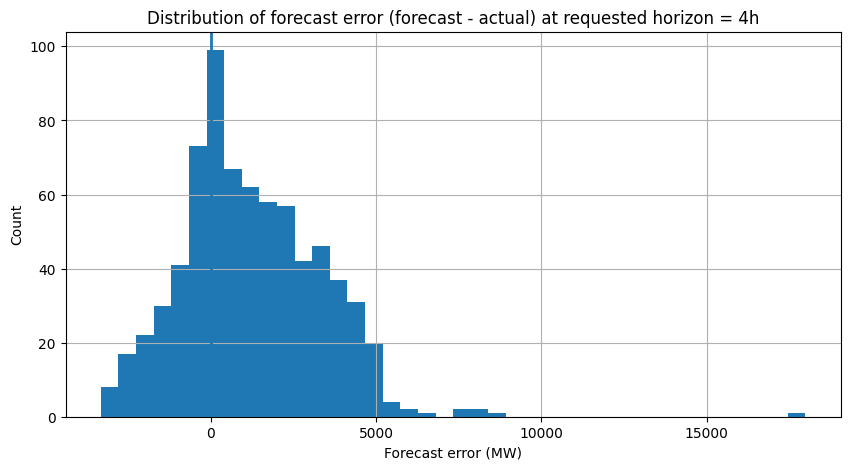

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(evaluation_h4_valid["error_mw"], bins=40)
plt.xlabel("Forecast error (MW)")
plt.ylabel("Count")
plt.title("Distribution of forecast error (forecast - actual) at requested horizon = 4h")
plt.axvline(0, linewidth=2)
plt.show()

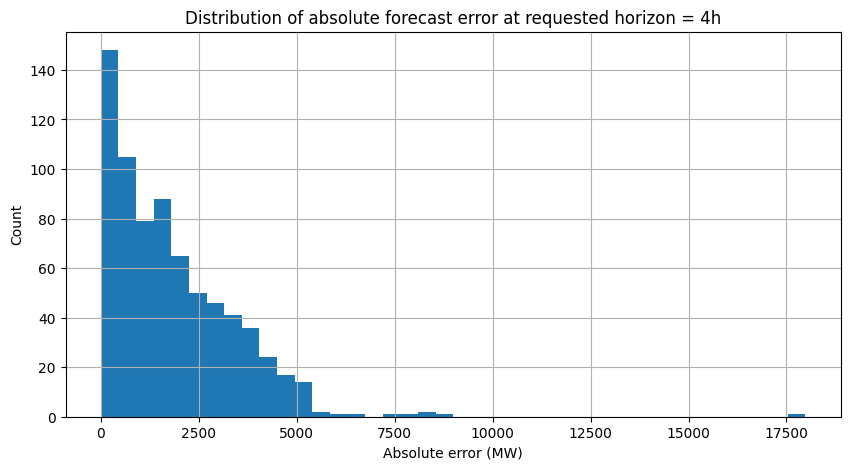

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(evaluation_h4_valid["abs_error_mw"], bins=40)
plt.xlabel("Absolute error (MW)")
plt.ylabel("Count")
plt.title("Distribution of absolute forecast error at requested horizon = 4h")
plt.show()

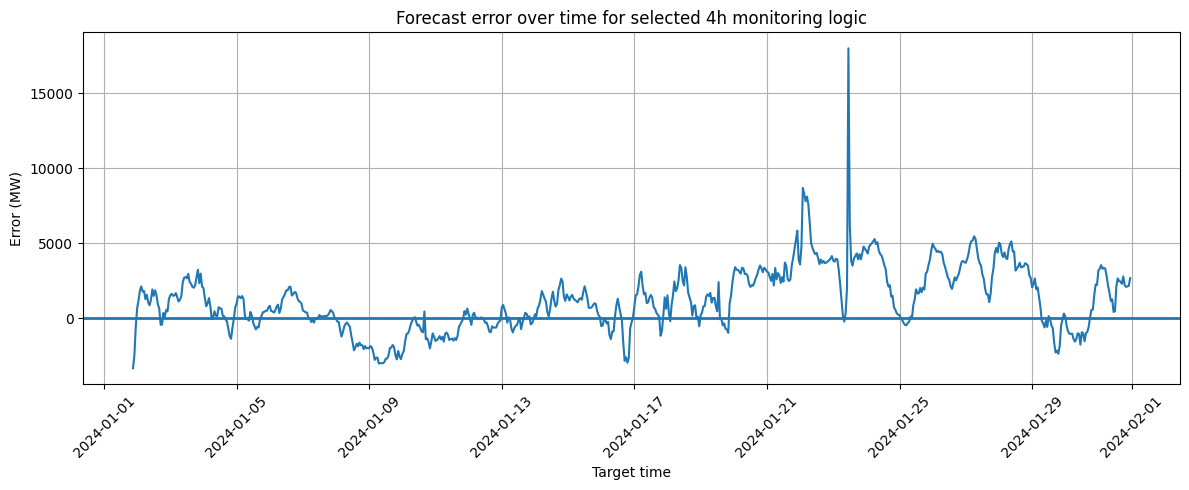

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(
    evaluation_h4_valid["startTime"],
    evaluation_h4_valid["error_mw"],
)
plt.axhline(0, linewidth=2)
plt.xlabel("Target time")
plt.ylabel("Error (MW)")
plt.title("Forecast error over time for selected 4h monitoring logic")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
bias_share = pd.Series({
    "overprediction_share": (evaluation_h4_valid["error_mw"] > 0).mean(),
    "underprediction_share": (evaluation_h4_valid["error_mw"] < 0).mean(),
    "exact_match_share": (evaluation_h4_valid["error_mw"] == 0).mean(),
})

bias_share.to_frame("value")

,value
overprediction_share,0.705394
underprediction_share,0.294606
exact_match_share,0.000000


## Interpretation

This section helps answer:

1. Are the forecasts centered around zero error, or biased?
2. How large is the typical error?
3. How bad are tail outcomes (p95 / p99)?
4. Are errors stable across time, or clustered in certain periods?

A positive mean and median error indicates systematic overprediction.
Large p95/p99 absolute errors indicate operational risk in relying too heavily on point forecasts.

## Key findings so far

Using the application rule of selecting the latest forecast published at least 4 hours before each target time:

- Forecast coverage is only about 48.6% because the forecast target times are mostly hourly, while actuals are half-hourly.
- Among the rows with valid forecasts, the selected forecasts are usually older than 4 hours in practice. The effective horizon has median 9.5 hours and mean 11.2 hours.
- Forecast errors show a strong positive bias:
  - mean error = +1226.6 MW
  - median error = +1001 MW
  - overprediction share = 70.5%

This indicates that, in this evaluation setup, the forecast tends to overestimate wind generation.

The size of the errors is also material:
- mean absolute error = 1838 MW
- p95 absolute error = 4613 MW
- p99 absolute error = 6158 MW

Therefore, these forecasts should be interpreted cautiously if they are used for operational planning or estimating reliably available wind power.

## 4. Error vs effective forecast horizon

Although the monitoring rule is based on a requested horizon of 4 hours, the actual selected forecasts are often much older because forecasts are only published at discrete times.

This section checks whether forecast error becomes worse as the effective horizon increases.

In [26]:
horizon_error_summary = (
    evaluation_h4_valid
    .groupby("effective_horizon_hours")
    .agg(
        count=("error_mw", "size"),
        mean_error_mw=("error_mw", "mean"),
        median_error_mw=("error_mw", "median"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p90_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.90)),
    )
    .reset_index()
    .sort_values("effective_horizon_hours")
)

horizon_error_summary

,effective_horizon_hours,count,mean_error_mw,median_error_mw,mean_abs_error_mw,median_abs_error_mw,p90_abs_error_mw
0,4.5,61,1463.114754,988.0,1918.622951,1342.0,4386.0
1,5.5,91,1374.879121,1162.0,1950.351648,1495.0,4348.0
2,6.5,91,1435.681319,1213.0,1937.681319,1454.0,4403.0
3,7.5,60,1494.700000,1144.5,1994.400000,1453.0,4456.1
4,8.5,30,1198.633333,712.0,1781.833333,1349.5,4647.7
5,9.5,30,1144.400000,860.0,1696.066667,1090.5,4679.0
6,10.5,30,1129.666667,644.5,1647.000000,1046.5,4058.6
7,11.5,30,1192.366667,1156.0,1654.100000,1258.0,3751.2
8,12.5,30,1680.100000,1071.5,2261.500000,1515.0,4202.7
9,13.5,30,1284.300000,1412.5,1797.566667,1575.0,3257.2


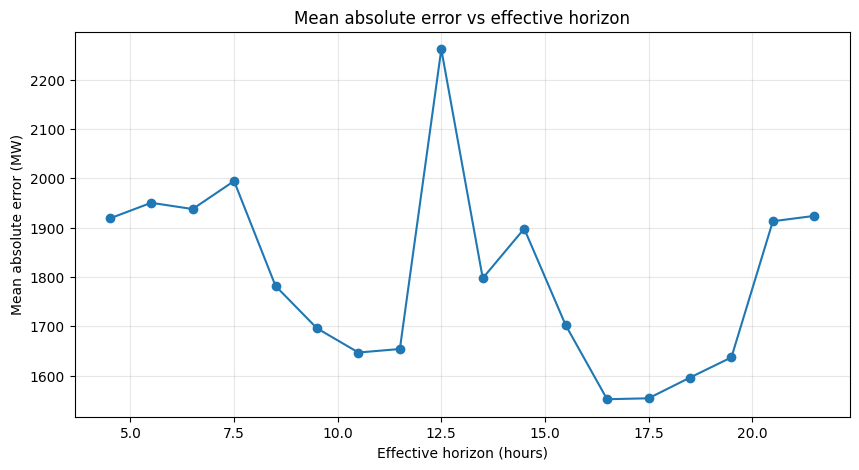

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(
    horizon_error_summary["effective_horizon_hours"],
    horizon_error_summary["mean_abs_error_mw"],
    marker="o",
)
plt.xlabel("Effective horizon (hours)")
plt.ylabel("Mean absolute error (MW)")
plt.title("Mean absolute error vs effective horizon")
plt.grid(True, alpha=0.3)
plt.show()

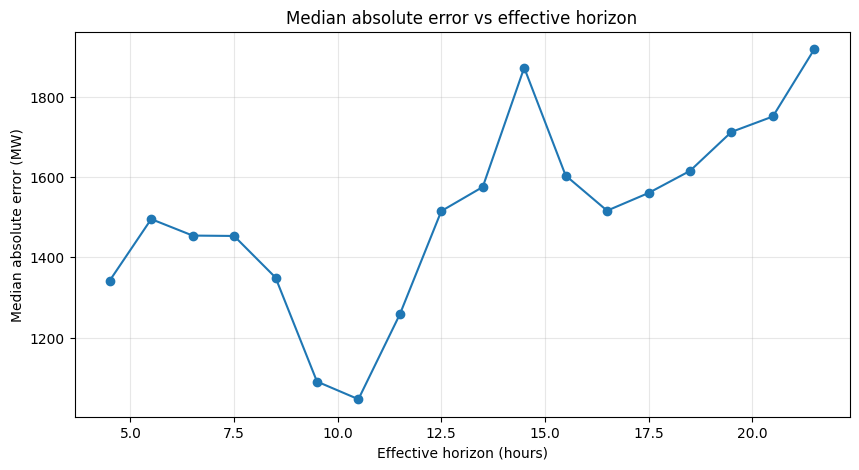

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(
    horizon_error_summary["effective_horizon_hours"],
    horizon_error_summary["median_abs_error_mw"],
    marker="o",
)
plt.xlabel("Effective horizon (hours)")
plt.ylabel("Median absolute error (MW)")
plt.title("Median absolute error vs effective horizon")
plt.grid(True, alpha=0.3)
plt.show()

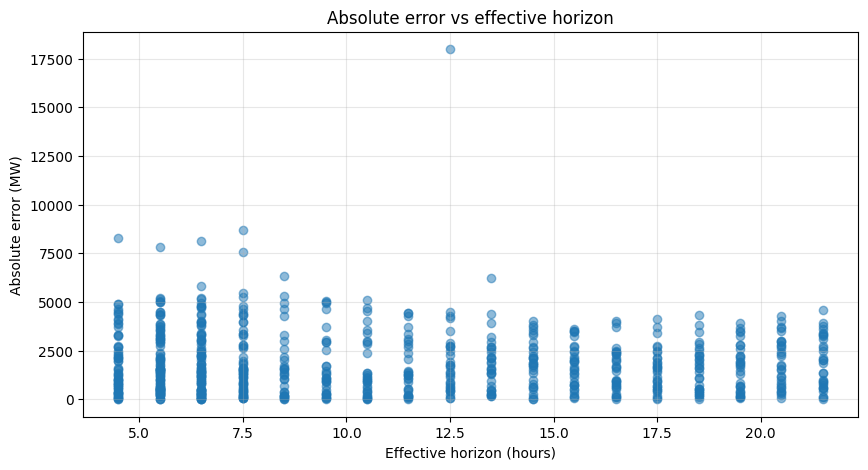

In [29]:
plt.figure(figsize=(10, 5))
plt.scatter(
    evaluation_h4_valid["effective_horizon_hours"],
    evaluation_h4_valid["abs_error_mw"],
    alpha=0.5,
)
plt.xlabel("Effective horizon (hours)")
plt.ylabel("Absolute error (MW)")
plt.title("Absolute error vs effective horizon")
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
corr_value = evaluation_h4_valid["effective_horizon_hours"].corr(
    evaluation_h4_valid["abs_error_mw"]
)

pd.Series({
    "correlation_between_effective_horizon_and_abs_error": corr_value
}).to_frame("value")

,value
correlation_between_effective_horizon_and_abs_error,-0.048328


## Interpretation

If forecast quality declines with age, we would expect absolute error to rise as effective horizon increases.

This is an important nuance for the app design:
a user may think they are viewing a "4-hour forecast", but in practice many displayed points are based on substantially older forecasts. Therefore, part of the observed error may be driven by the mismatch between requested horizon and effective horizon.

## 5. Error by time of day

Forecast performance may vary by hour of day. This section checks whether certain times consistently have larger forecast errors.

In [31]:
hourly_error_summary = (
    evaluation_h4_valid
    .groupby("hour_of_day")
    .agg(
        count=("error_mw", "size"),
        mean_error_mw=("error_mw", "mean"),
        median_error_mw=("error_mw", "median"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p90_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.90)),
    )
    .reset_index()
    .sort_values("hour_of_day")
)

hourly_error_summary

,hour_of_day,count,mean_error_mw,median_error_mw,mean_abs_error_mw,median_abs_error_mw,p90_abs_error_mw
0,0,30,1431.133333,909.5,1856.800000,1515.0,3921.5
1,1,30,1436.666667,1204.0,1883.400000,1464.0,4365.5
2,2,30,1594.666667,1134.0,2044.666667,1479.5,4348.1
3,3,30,1613.000000,1172.0,2060.866667,1435.5,4471.5
4,4,30,1628.766667,1470.5,2192.233333,1518.0,4547.1
5,5,30,1612.333333,1421.5,2094.933333,1513.0,4477.2
6,6,30,1394.733333,1144.5,1944.133333,1325.5,4521.3
7,7,30,1198.633333,712.0,1781.833333,1349.5,4647.7
8,8,30,1144.400000,860.0,1696.066667,1090.5,4679.0
9,9,30,1129.666667,644.5,1647.000000,1046.5,4058.6


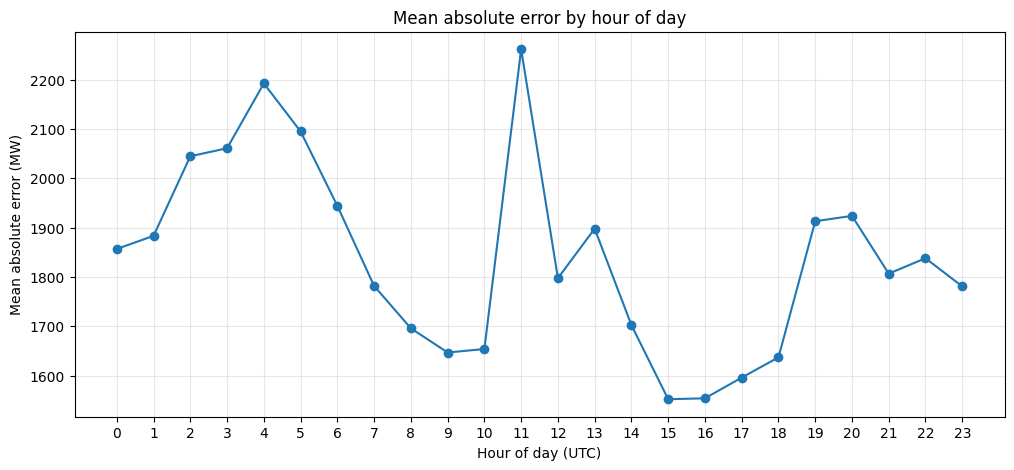

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(
    hourly_error_summary["hour_of_day"],
    hourly_error_summary["mean_abs_error_mw"],
    marker="o",
)
plt.xlabel("Hour of day (UTC)")
plt.ylabel("Mean absolute error (MW)")
plt.title("Mean absolute error by hour of day")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

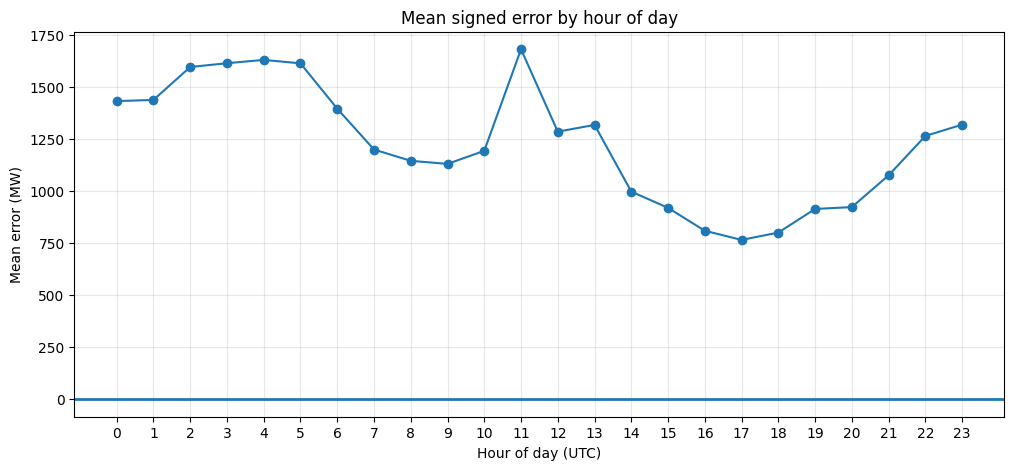

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(
    hourly_error_summary["hour_of_day"],
    hourly_error_summary["mean_error_mw"],
    marker="o",
)
plt.axhline(0, linewidth=2)
plt.xlabel("Hour of day (UTC)")
plt.ylabel("Mean error (MW)")
plt.title("Mean signed error by hour of day")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation

This section helps identify whether:
- forecast accuracy is uniformly distributed across the day, or
- some hours are systematically more difficult, and
- the positive bias is present throughout the day or concentrated in specific periods.

## 6. Historical actual wind generation and reliable available capacity

The second part of the assignment asks:

> Based on the past wind generation data, how many MW of wind power can we reliably expect to be available to meet electricity demand?

This is inherently subjective, so I define reliability using historical quantiles of actual generation.

Interpretation:
- P50 generation: level exceeded 50% of the time
- P75 generation: level exceeded 75% of the time
- P90 generation: level exceeded 90% of the time

A more conservative operational recommendation should be closer to the lower quantiles, because those represent generation that is available more consistently.

In [34]:
actual_generation_summary = pd.Series({
    "count": len(actuals),
    "mean_mw": actuals["generation"].mean(),
    "median_mw": actuals["generation"].median(),
    "min_mw": actuals["generation"].min(),
    "p10_mw": actuals["generation"].quantile(0.10),
    "p25_mw": actuals["generation"].quantile(0.25),
    "p50_mw": actuals["generation"].quantile(0.50),
    "p75_mw": actuals["generation"].quantile(0.75),
    "p90_mw": actuals["generation"].quantile(0.90),
    "max_mw": actuals["generation"].max(),
    "std_mw": actuals["generation"].std(),
})

actual_generation_summary.to_frame("value")

,value
count,1488.000000
mean_mw,9848.730511
median_mw,9863.500000
min_mw,0.000000
p10_mw,5087.900000
p25_mw,6732.500000
p50_mw,9863.500000
p75_mw,13105.250000
p90_mw,14809.600000
max_mw,16662.000000


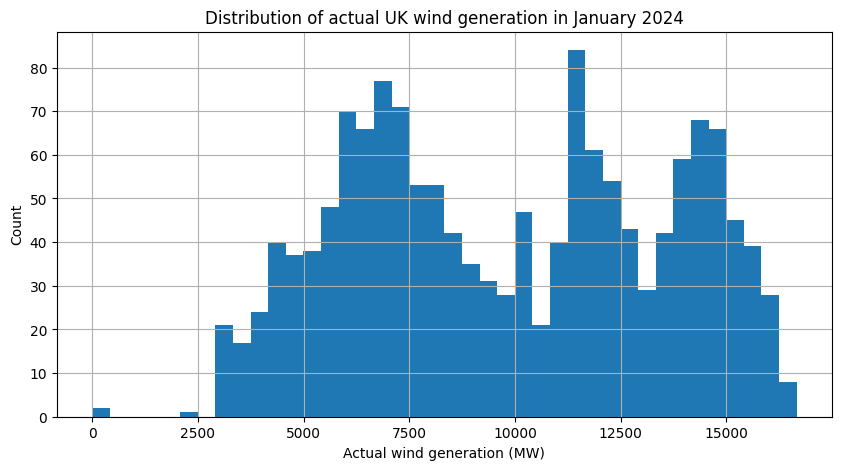

In [35]:
plt.figure(figsize=(10, 5))
plt.hist(actuals["generation"], bins=40)
plt.xlabel("Actual wind generation (MW)")
plt.ylabel("Count")
plt.title("Distribution of actual UK wind generation in January 2024")
plt.show()

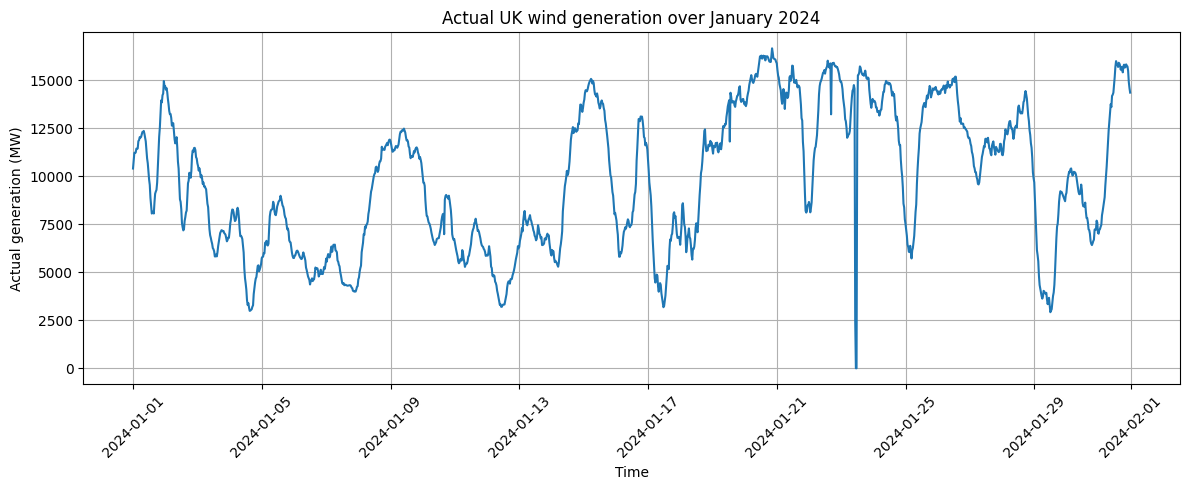

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(actuals["startTime"], actuals["generation"])
plt.xlabel("Time")
plt.ylabel("Actual generation (MW)")
plt.title("Actual UK wind generation over January 2024")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
daily_generation_summary = (
    actuals.assign(date=actuals["startTime"].dt.date)
    .groupby("date")
    .agg(
        daily_mean_mw=("generation", "mean"),
        daily_min_mw=("generation", "min"),
        daily_max_mw=("generation", "max"),
        daily_p10_mw=("generation", lambda s: s.quantile(0.10)),
    )
    .reset_index()
)

daily_generation_summary.head()

,date,daily_mean_mw,daily_min_mw,daily_max_mw,daily_p10_mw
0,2024-01-01,11206.395833,8058,14958,8592.3
1,2024-01-02,10929.854167,7180,14690,7810.6
2,2024-01-03,7750.020833,5823,10672,6077.2
3,2024-01-04,5724.520833,2988,8359,3193.2
4,2024-01-05,7442.666667,5740,8984,5946.5


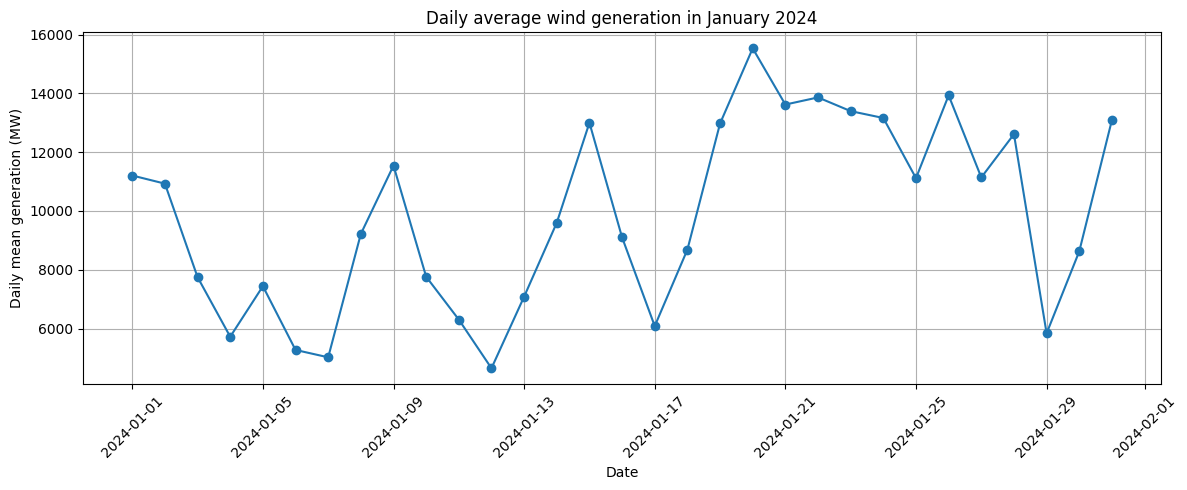

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(daily_generation_summary["date"], daily_generation_summary["daily_mean_mw"], marker="o")
plt.xlabel("Date")
plt.ylabel("Daily mean generation (MW)")
plt.title("Daily average wind generation in January 2024")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
reliability_table = pd.Series({
    "available_at_least_50pct_of_time_mw": actuals["generation"].quantile(0.50),
    "available_at_least_75pct_of_time_mw": actuals["generation"].quantile(0.25),
    "available_at_least_90pct_of_time_mw": actuals["generation"].quantile(0.10),
})

reliability_table.to_frame("value")

,value
available_at_least_50pct_of_time_mw,9863.5
available_at_least_75pct_of_time_mw,6732.5
available_at_least_90pct_of_time_mw,5087.9


## 7. Recommendation: how much wind power can be relied on?

Using January 2024 actual UK wind generation:

- Mean generation was approximately **9849 MW**
- Median generation was approximately **9864 MW**
- Generation was at least **5,088 MW** for 90% of the half-hourly timestamps
- Generation was at least **6,733 MW** for 75% of the timestamps
- Generation was at least **9,864 MW** for 50% of the timestamps

My recommendation is to use the **90% availability level** as the conservative estimate of wind power that can be reliably expected to meet electricity demand. This is the most defensible choice if the goal is dependable planning rather than optimistic expectation.

Therefore, based on January 2024 data, a reasonable conservative estimate of reliably available wind power is **5,100 MW**.

A less conservative planner could use the 75% availability level (**6,700 MW**), but this accepts a higher risk that actual wind generation will fall below that level.

The mean generation is much higher than the conservative reliability estimate, but mean values are not suitable for firm planning because wind generation is highly variable. A reliability recommendation should be based on lower quantiles rather than averages.

## 8. Final conclusions

This analysis led to the following conclusions:

1. The app logic for selecting the latest forecast at least 4 hours before the target time was implemented correctly.
2. Forecast coverage is only about 48.6% because the actual data is half-hourly while forecast target times are mostly hourly.
3. The selected forecasts are often older than the requested 4 hours, with median effective horizon 9.5 hours.
4. Forecasts show a clear positive bias, with mean error of about +1227 MW and overprediction in about 70.5% of valid cases.
5. Forecast errors are substantial, with mean absolute error about 1838 MW and p95 absolute error above 4600 MW.
6. Error does not show a strong monotonic relationship with effective horizon in this sample.
7. Forecast performance varies across the day, with some hours showing meaningfully larger errors.
8. For planning reliable wind availability, lower quantiles of actual generation are more appropriate than the mean. A conservative recommendation is to use the generation level exceeded 90% of the time.

## 9. Error analysis using the raw forecast dataset across forecast horizons

The earlier analysis focused on the monitoring app logic, which selects one forecast per target time using a requested horizon of 4 hours.

However, the assignment also asks how forecast error varies with forecast horizon.  
To answer that properly, I now analyze the raw forecast dataset directly.

Method:
- Join every raw forecast row with the corresponding actual generation using `startTime`
- Compute forecast error for every raw forecast row
- Group results by `horizon_hours`
- Study how error metrics change as the forecast horizon increases

In [40]:
raw_eval = forecasts.merge(
    actuals[["startTime", "generation"]],
    on="startTime",
    how="inner",
    suffixes=("_forecast", "_actual")
).rename(columns={
    "generation_forecast": "forecast_generation",
    "generation_actual": "actual_generation"
})

raw_eval["error_mw"] = raw_eval["forecast_generation"] - raw_eval["actual_generation"]
raw_eval["abs_error_mw"] = raw_eval["error_mw"].abs()

print("Raw evaluation shape:", raw_eval.shape)
raw_eval.head()

Raw evaluation shape: (9200, 7)


,publishTime,startTime,forecast_generation,horizon_hours,actual_generation,error_mw,abs_error_mw
0,2024-01-01 02:30:00+00:00,2024-01-01 21:00:00+00:00,9426,18.5,13953,-4527,4527
1,2024-01-01 04:30:00+00:00,2024-01-01 21:00:00+00:00,9432,16.5,13953,-4521,4521
2,2024-01-01 07:30:00+00:00,2024-01-01 21:00:00+00:00,10065,13.5,13953,-3888,3888
3,2024-01-01 09:30:00+00:00,2024-01-01 21:00:00+00:00,10065,11.5,13953,-3888,3888
4,2024-01-01 11:30:00+00:00,2024-01-01 21:00:00+00:00,10072,9.5,13953,-3881,3881


In [41]:
raw_eval[["horizon_hours", "error_mw", "abs_error_mw"]].describe()

,horizon_hours,error_mw,abs_error_mw
count,9200.000000,9200.000000,9200.000000
mean,27.916957,1406.910761,2071.510543
std,11.952942,2251.249998,1660.155777
min,0.500000,-4788.000000,0.000000
25%,18.500000,-84.000000,732.750000
50%,28.500000,1318.000000,1806.500000
75%,38.500000,2932.250000,3058.000000
max,48.000000,18076.000000,18076.000000


In [42]:
raw_horizon_summary = (
    raw_eval
    .groupby("horizon_hours")
    .agg(
        count=("error_mw", "size"),
        mean_error_mw=("error_mw", "mean"),
        median_error_mw=("error_mw", "median"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p90_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.90)),
        p95_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.95)),
        p99_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.99)),
    )
    .reset_index()
    .sort_values("horizon_hours")
)

raw_horizon_summary.head(15)

,horizon_hours,count,mean_error_mw,median_error_mw,mean_abs_error_mw,median_abs_error_mw,p90_abs_error_mw,p95_abs_error_mw,p99_abs_error_mw
0,0.5,31,1313.516129,969.0,1776.806452,1304.0,4159.0,4456.50,4593.90
1,1.5,30,1438.566667,1028.0,1866.566667,1506.0,3918.8,4764.35,5015.92
2,2.5,61,1226.377049,992.0,1786.770492,1366.0,4108.0,4325.00,4836.80
3,3.5,61,1433.508197,815.0,1919.803279,1443.0,4317.0,4784.00,7259.80
4,4.5,61,1463.114754,988.0,1918.622951,1342.0,4386.0,4622.00,6254.20
5,5.5,91,1374.879121,1162.0,1950.351648,1495.0,4348.0,4992.00,5475.90
6,6.5,91,1435.681319,1213.0,1937.681319,1454.0,4403.0,4863.00,6069.30
7,7.0,1,4316.000000,4316.0,4316.000000,4316.0,4316.0,4316.00,4316.00
8,7.5,91,1438.230769,1039.0,1959.197802,1454.0,4365.0,4705.50,7688.90
9,8.0,1,4976.000000,4976.0,4976.000000,4976.0,4976.0,4976.00,4976.00


In [43]:
raw_horizon_summary.tail(15)

,horizon_hours,count,mean_error_mw,median_error_mw,mean_abs_error_mw,median_abs_error_mw,p90_abs_error_mw,p95_abs_error_mw,p99_abs_error_mw
75,41.0,1,1659.000000,1659.0,1659.000000,1659.0,1659.0,1659.00,1659.00
76,41.5,233,1515.665236,1802.0,2224.987124,2199.0,4082.6,4725.80,7094.60
77,42.0,1,2351.000000,2351.0,2351.000000,2351.0,2351.0,2351.00,2351.00
78,42.5,233,1550.763948,1788.0,2298.660944,2282.0,4044.4,4561.80,6679.28
79,43.0,1,2245.000000,2245.0,2245.000000,2245.0,2245.0,2245.00,2245.00
80,43.5,232,1611.064655,1799.5,2382.840517,2224.0,4224.9,4777.15,7102.44
81,44.0,1,2643.000000,2643.0,2643.000000,2643.0,2643.0,2643.00,2643.00
82,44.5,232,1591.564655,1864.0,2386.978448,2280.0,4301.4,4697.50,6680.30
83,45.0,1,2914.000000,2914.0,2914.000000,2914.0,2914.0,2914.00,2914.00
84,45.5,231,1571.125541,1839.0,2374.329004,2311.0,4287.0,4763.50,6602.10


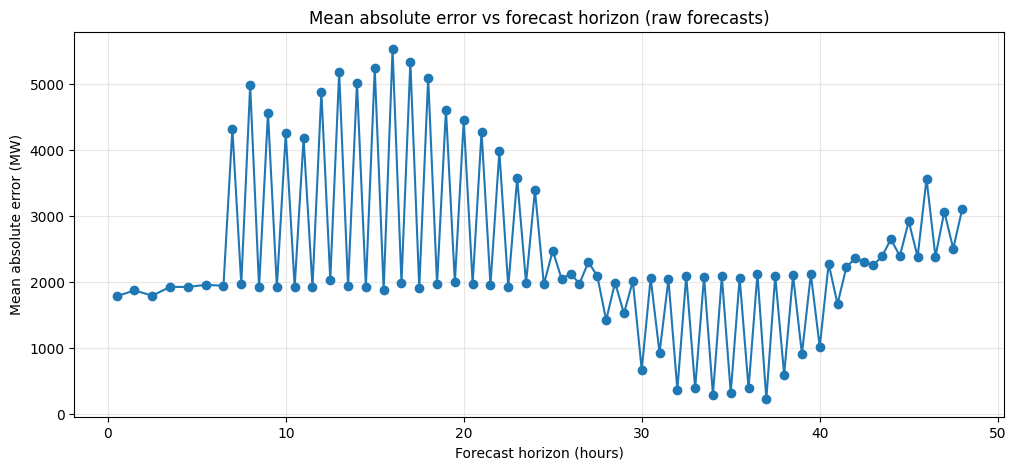

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(
    raw_horizon_summary["horizon_hours"],
    raw_horizon_summary["mean_abs_error_mw"],
    marker="o"
)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Mean absolute error (MW)")
plt.title("Mean absolute error vs forecast horizon (raw forecasts)")
plt.grid(True, alpha=0.3)
plt.show()

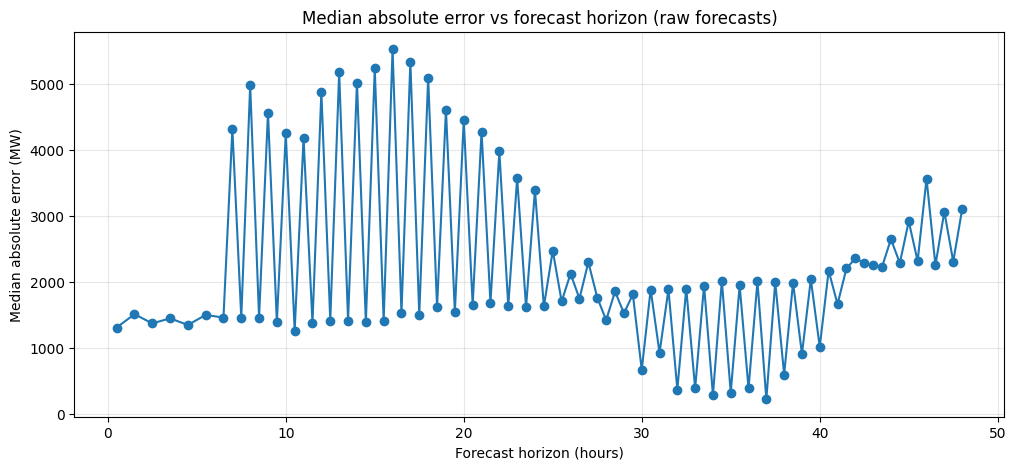

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(
    raw_horizon_summary["horizon_hours"],
    raw_horizon_summary["median_abs_error_mw"],
    marker="o"
)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Median absolute error (MW)")
plt.title("Median absolute error vs forecast horizon (raw forecasts)")
plt.grid(True, alpha=0.3)
plt.show()

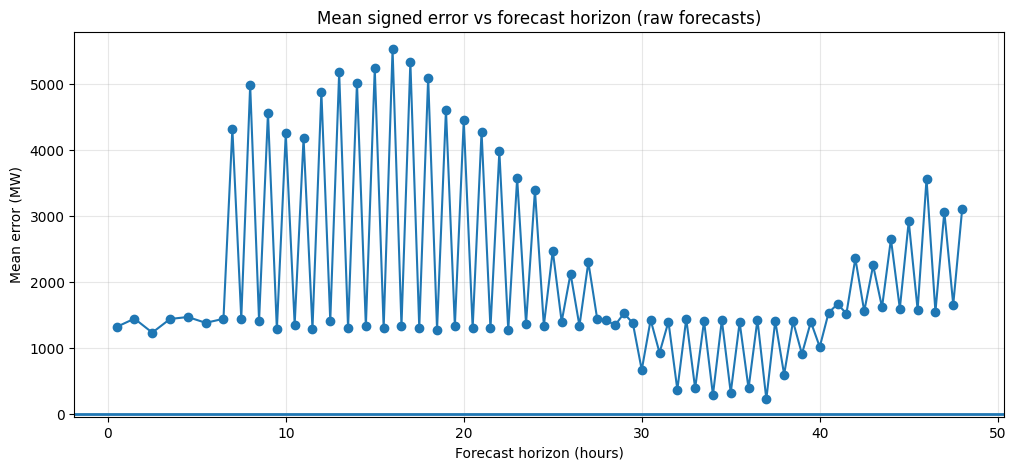

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(
    raw_horizon_summary["horizon_hours"],
    raw_horizon_summary["mean_error_mw"],
    marker="o"
)
plt.axhline(0, linewidth=2)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Mean error (MW)")
plt.title("Mean signed error vs forecast horizon (raw forecasts)")
plt.grid(True, alpha=0.3)
plt.show()

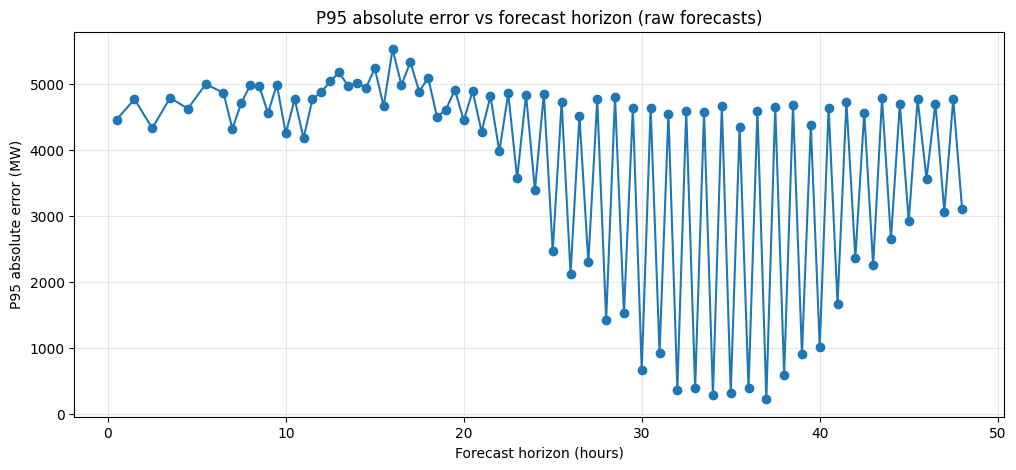

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(
    raw_horizon_summary["horizon_hours"],
    raw_horizon_summary["p95_abs_error_mw"],
    marker="o"
)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("P95 absolute error (MW)")
plt.title("P95 absolute error vs forecast horizon (raw forecasts)")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
raw_corr_abs = raw_eval["horizon_hours"].corr(raw_eval["abs_error_mw"])
raw_corr_signed = raw_eval["horizon_hours"].corr(raw_eval["error_mw"])

pd.Series({
    "correlation_horizon_vs_abs_error": raw_corr_abs,
    "correlation_horizon_vs_signed_error": raw_corr_signed,
}).to_frame("value")

,value
correlation_horizon_vs_abs_error,0.079224
correlation_horizon_vs_signed_error,0.029893


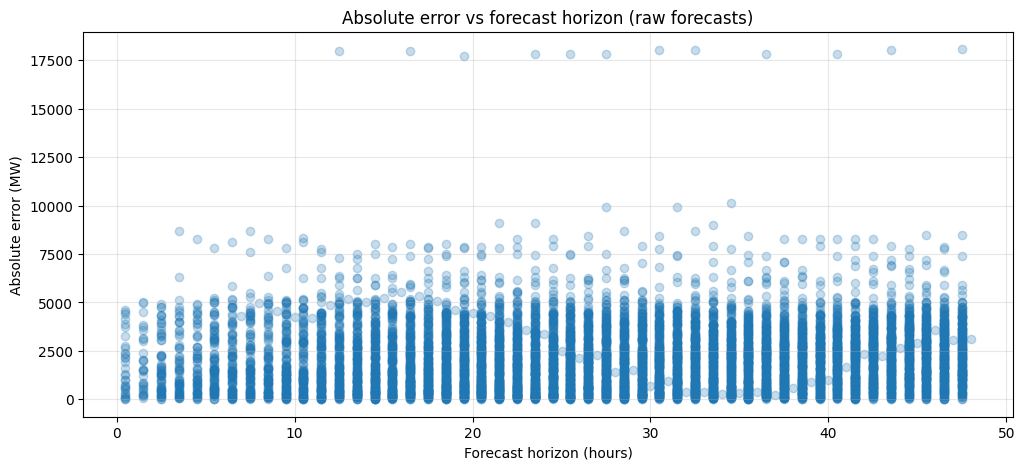

In [51]:
plt.figure(figsize=(12, 5))
plt.scatter(
    raw_eval["horizon_hours"],
    raw_eval["abs_error_mw"],
    alpha=0.25
)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Absolute error (MW)")
plt.title("Absolute error vs forecast horizon (raw forecasts)")
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation

This section shows how forecast quality changes with horizon when using the raw dataset directly.

Questions to answer:
- Does absolute error rise as horizon increases?
- Does signed error reveal any consistent bias at short or long horizons?
- Do tail errors (for example p95) become materially worse at longer horizons?

This analysis is complementary to the monitoring-app analysis:
- the app analysis explains the end-user view
- the raw horizon analysis explains the forecasting behavior more directly

In [52]:
raw_eval["horizon_bucket"] = pd.cut(
    raw_eval["horizon_hours"],
    bins=[0, 6, 12, 24, 36, 48],
    include_lowest=True
)

bucket_summary = (
    raw_eval
    .groupby("horizon_bucket")
    .agg(
        count=("error_mw", "size"),
        mean_error_mw=("error_mw", "mean"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p95_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.95)),
    )
    .reset_index()
)

bucket_summary

,horizon_bucket,count,mean_error_mw,mean_abs_error_mw,median_abs_error_mw,p95_abs_error_mw
0,"(-0.001, 6.0]",335,1374.605970,1885.662687,1452.0,4755.30
1,"(6.0, 12.0]",669,1380.965620,1950.038864,1400.0,4980.20
2,"(12.0, 24.0]",2561,1324.918391,1962.296759,1546.0,4918.00
3,"(24.0, 36.0]",2858,1385.428971,2031.586424,1845.5,4621.15
4,"(36.0, 48.0]",2777,1514.781419,2265.001080,2164.0,4694.00


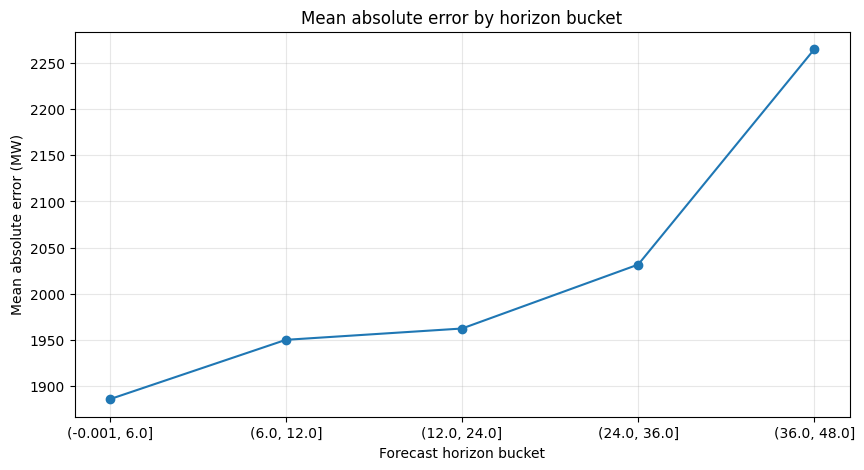

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(
    bucket_summary["horizon_bucket"].astype(str),
    bucket_summary["mean_abs_error_mw"],
    marker="o"
)
plt.xlabel("Forecast horizon bucket")
plt.ylabel("Mean absolute error (MW)")
plt.title("Mean absolute error by horizon bucket")
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation of forecast error vs horizon

Using the raw forecast dataset allows direct comparison of forecast quality across horizons from 0.5 hours to 48 hours.

Several observations emerge:

1. **Forecast error increases gradually with horizon.**

Mean absolute error rises from roughly **1.9 GW for short horizons (0–6 hours)** to about **2.3 GW for long horizons (36–48 hours)**.  
This confirms the expected pattern that longer-horizon forecasts are generally less accurate, although the degradation is gradual rather than dramatic.

2. **The forecasts show a persistent positive bias.**

Across most horizons, the mean forecast error is between **+1.3 GW and +1.5 GW**, indicating that the forecasting system tends to **overestimate wind generation**.

3. **Tail errors are large.**

The 95th percentile absolute error is around **4.7–5.0 GW** across many horizons.  
This means that while typical errors are around 2 GW, there are still frequent situations where the forecast misses by several gigawatts.

4. **Short-term forecasts are somewhat better, but still imperfect.**

Even for horizons under 6 hours, the mean absolute error remains close to **1.9 GW**, indicating that near-term wind forecasting remains challenging.

Overall, these results suggest that while forecast accuracy degrades with horizon, **the dominant characteristics of the forecast system are bias and large variability**, rather than purely horizon-driven error growth.

## 10. Overall takeaway

This notebook evaluated the UK national wind generation forecasts for January 2024 from two perspectives:

### A. Monitoring-app perspective
Using the app rule of selecting the latest forecast published at least 4 hours before each target time:
- forecast coverage is limited because forecast target times are mostly hourly while actuals are half-hourly
- effective forecast age is often greater than the requested 4 hours
- forecast errors show a strong positive bias and substantial tail risk

### B. Raw forecast perspective
Using all raw forecast rows directly:
- forecast quality can be compared across horizons
- this helps determine whether longer-horizon forecasts are materially less accurate

### Reliability recommendation
For planning how much wind generation can reliably contribute to demand, lower quantiles of actual generation are more appropriate than the mean.

Based on January 2024 actual generation:
- conservative reliable level (available 90% of the time): about **5.1 GW**
- moderate level (available 75% of the time): about **6.7 GW**
- median level (available 50% of the time): about **9.9 GW**

Therefore, a prudent planning recommendation is to treat **about 5.1 GW** as the reliably available wind generation level, while recognizing that actual output can vary materially over time.